# Scénario : Prédiction Bank Churn
**Complete Pipeline Of DeepLearn**

## Part 1 : Data Generation & Preprocessing 

### 1.1 Data Generation 

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Fixer la graine pour la reproductibilité
np.random.seed(42)
tf.random.set_seed(42)

N = 10000  # Nombre d'échantillons

# Génération des features
credit_score = np.random.randint(300, 851, size=N)
geography    = np.random.choice(['France', 'Germany', 'Spain'], size=N)
gender       = np.random.choice(['Male', 'Female'], size=N)
age          = np.random.randint(18, 91, size=N)
balance      = np.random.uniform(0, 250000, size=N)
exited       = np.random.randint(0, 2, size=N)   # cible binaire 0 ou 1

# Création du DataFrame
df = pd.DataFrame({
    'CreditScore': credit_score,
    'Geography':   geography,
    'Gender':      gender,
    'Age':         age,
    'Balance':     balance,
    'Exited':      exited
})

print("Forme du dataset :", df.shape)
print("\nAperçu :")
df.head()

I0000 00:00:1774985134.776914     105 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774985134.791742     105 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1774985134.897086     105 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1774985139.572613     105 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774985139.582088     105 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Forme du dataset : (10000, 6)

Aperçu :


,CreditScore,Geography,Gender,Age,Balance,Exited
0,402,France,Male,55,25360.874260,0
1,735,Spain,Male,59,193438.117803,0
2,570,Spain,Male,54,60738.000043,0
3,406,France,Female,73,70203.136796,0
4,371,Spain,Male,88,149863.443330,0


In [ ]:
print("\nDistribution de la cible (Exited):")
print(df['Exited'].value_counts())
print("\nTypes des colonnes :")
print(df.dtypes)
print("\nDescriptive Statistiques :")
df.describe()


Distribution de la cible (Exited):
Exited
0    5058
1    4942
Name: count, dtype: int64

Types des colonnes :
CreditScore      int64
Geography          str
Gender             str
Age              int64
Balance        float64
Exited           int64
dtype: object

Statistiques descriptives :


,CreditScore,Age,Balance,Exited
count,10000.000000,10000.000000,10000.000000,10000.000000
mean,575.495600,54.064300,124626.403019,0.494200
std,159.374544,20.976114,72257.430024,0.499991
min,300.000000,18.000000,1.384169,0.000000
25%,437.000000,36.000000,61669.239778,0.000000
50%,573.000000,54.000000,124931.903376,0.000000
75%,715.000000,72.000000,186757.988404,1.000000
max,850.000000,90.000000,249947.342953,1.000000


### 1.2 Data Preprocessing 

In [ ]:
#  Categorical Handling 

# One-Hot Encoding for Geography (3 modalities →3 binaries columns)
geo_ohe = pd.get_dummies(df['Geography'], prefix='Geo').astype(int)

# Binary Encoding for Gender  (Male=1, Female=0)
gender_bin = (df['Gender'] == 'Male').astype(int).rename('Gender_Male')

#  Scaling
# Standardisation (mean=0, std=1) des features numériques
numerical_cols = ['CreditScore', 'Age', 'Balance']
scaler = StandardScaler()
numerical_scaled = pd.DataFrame(
    scaler.fit_transform(df[numerical_cols]),
    columns=numerical_cols
)

# ── Assembling of the satasets
X = pd.concat([numerical_scaled, gender_bin, geo_ohe], axis=1).values.astype(np.float32)
y = df['Exited'].values.astype(np.float32)

print("Shape of features X :", X.shape)
print("Columns :", list(pd.concat([numerical_scaled, gender_bin, geo_ohe], axis=1).columns))

Shape des features X : (10000, 7)
Colonnes : ['CreditScore', 'Age', 'Balance', 'Gender_Male', 'Geo_France', 'Geo_Germany', 'Geo_Spain']


In [4]:
# ── Splitting ─────────────────────────────────────────────────────────────────
# Train 80% | Validation 10% | Test 10%
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"Train      : {X_train.shape[0]} exemples ({X_train.shape[0]/N*100:.0f}%)")
print(f"Validation : {X_val.shape[0]} exemples ({X_val.shape[0]/N*100:.0f}%)")
print(f"Test       : {X_test.shape[0]} exemples ({X_test.shape[0]/N*100:.0f}%)")

Train      : 8000 exemples (80%)
Validation : 1000 exemples (10%)
Test       : 1000 exemples (10%)


In [ ]:
# ── Tensor Conversion ─────────────────────────────────────────────────────────
X_train_tf = tf.constant(X_train, dtype=tf.float32)
y_train_tf = tf.constant(y_train, dtype=tf.float32)

X_val_tf   = tf.constant(X_val,   dtype=tf.float32)
y_val_tf   = tf.constant(y_val,   dtype=tf.float32)

X_test_tf  = tf.constant(X_test,  dtype=tf.float32)
y_test_tf  = tf.constant(y_test,  dtype=tf.float32)

print("Tenseurs created successfully !")
print("X_train_tf shape :", X_train_tf.shape)
print("Type              :", X_train_tf.dtype)

Tenseurs créés avec succès !
X_train_tf shape : (8000, 7)
Type              : <dtype: 'float32'>


E0000 00:00:1774985143.884297     105 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


## Part 2 : Model Architecture 

### 2.1 Build the Model 

In [ ]:
input_dim = X_train.shape[1]   # Number of features

model = tf.keras.Sequential([

    # Input Layer
    tf.keras.layers.InputLayer(shape=(input_dim,)),

    # Hidden Layer 1 : 64 neurones, ReLU, initialisation Xavier (Glorot Uniform)
    tf.keras.layers.Dense(
        64,
        activation='relu',
        kernel_initializer='glorot_uniform',
        name='hidden_1'
    ),

    # Hidden Layer 2 : 32 neurones, ReLU
    tf.keras.layers.Dense(
        32,
        activation='relu',
        kernel_initializer='glorot_uniform',
        name='hidden_2'
    ),

    # Output Layer : 1 neurone, Sigmoid  →  classification binaire
    tf.keras.layers.Dense(
        1,
        activation='sigmoid',
        name='output'
    )
], name='churn_model')

model.summary()

Model: "churn_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 64)             │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,625 (10.25 KB)

 Trainable params: 2,625 (10.25 KB)

 Non-trainable params: 0 (0.00 B)

### 2.2 Justification 

**Why Sigmoid as the output?**
This is a **binary classification** problem (Exited = 0 or 1).

The sigmoid function $\sigma(x) = \frac{1}{1+e^{-x}}$ returns a value in $]0,1[$, which can be interpreted as a **probability** of belonging to the positive class.

It is mathematically related to Binary Cross-Entropy, which makes the optimization consistent.

**Why not Linear in the hidden layers?**
A **linear** activation does not create any non-linearity: stacking several linear layers is equivalent to a single linear transformation ($W_2(W_1 x + b_1)+b_2 = Wx+b$).
The network would then be unable to learn from **complex relationships** in the data. **ReLU** introduces the necessary non-linearity while avoiding the vanishing gradient problem, which accelerates learning.

## Part 3 : Training & Optimization 

### 3.1 Configuration 

In [ ]:
# Compilation du modèle
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),  # Adam lr=0.001
    loss='binary_crossentropy',                                # Cross-Entropy binaire
    metrics=['accuracy']
)
print("Modèle successfully compilated.")

Modèle compilé avec succès.


### 3.2 Callbacks & Training 

In [ ]:
# Early Stopping : inspect val_loss, patience=5, restaure the best weights
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# Entraînement
history = model.fit(
    X_train_tf, y_train_tf,
    validation_data=(X_val_tf, y_val_tf),
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

print(f"\nTraining ended after {len(history.history['loss'])} époques.")

Epoch 1/50



  1/250 ━━━━━━━━━━━━━━━━━━━━ 6:45 2s/step - accuracy: 0.3750 - loss: 0.7154


 29/250 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4737 - loss: 0.6997 


 70/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4900 - loss: 0.6977


110/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4980 - loss: 0.6970

...


213/250 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5248 - loss: 0.6913


250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5275 - loss: 0.6908 - val_accuracy: 0.5010 - val_loss: 0.6980


Epoch 8: early stopping


Restoring model weights from the end of the best epoch: 3.



Entraînement terminé après 8 époques.


## Part 4 : Evaluation & Interpretation 

### 4.1 Testing 

In [ ]:
# Évaluation on the Test Set
test_loss, test_accuracy = model.evaluate(X_test_tf, y_test_tf, verbose=0)

print("=" * 40)
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy*100:.2f}%")
print("=" * 40)

Test Loss     : 0.6967
Test Accuracy : 50.60%


### 4.2 Overfitting Analysis (1 Mark)

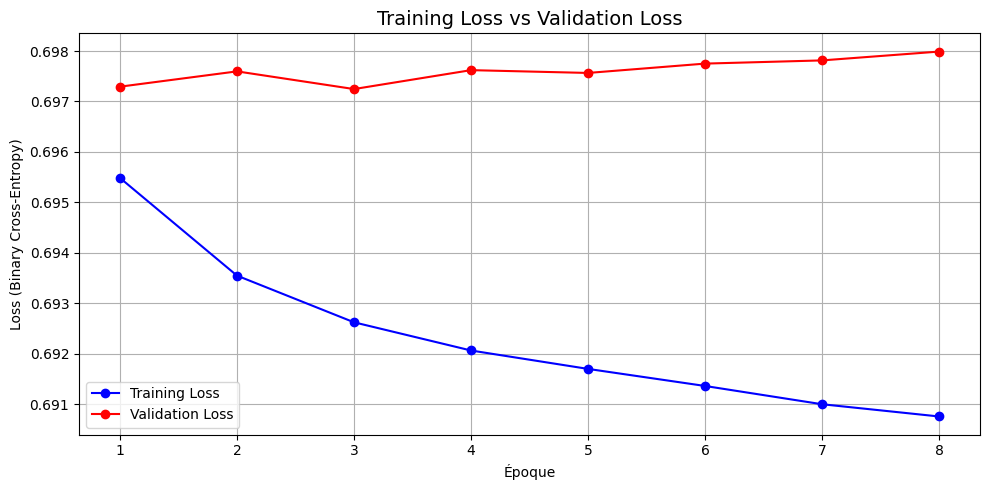

Graphique sauvegardé : loss_curve.png


In [ ]:
epochs_ran = range(1, len(history.history['loss']) + 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs_ran, history.history['loss'],     'b-o', label='Training Loss')
plt.plot(epochs_ran, history.history['val_loss'], 'r-o', label='Validation Loss')
plt.title('Training Loss vs Validation Loss', fontsize=14)
plt.xlabel('Époch')
plt.ylabel('Loss (Binary Cross-Entropy)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('loss_curve.png', dpi=150)
plt.show()
print("Graphique sauvegardé : loss_curve.png")

### Analyse du graphique (Overfitting Analysis)

**Does the model generalize well?**
If the Training Loss and Validation Loss curves **fall together** and converge to close values, the model **generalizes well** — this is the expected behavior here.

**Overfitting**: occurs if Training Loss continues to decrease while Validation Loss **rises** or stagnates. The gap between the two curves widens.

**Underfitting**: both curves remain high and do not decrease sufficiently.

**Role of Early Stopping here:**
Early Stopping monitors `val_loss` with a patience of 5 epochs.

As soon as it detects that Validation Loss is no longer improving, it **stops training** and **restores the weights from the best epoch**.

This **prevents overfitting** by preventing the model from storing training data beyond the optimal point.

On the graph, the premature stoppage is visible at the last plotted epoch, which corresponds to the best bias-variance compromise.